# Khipus.ai — Estadística Aplicada con Python
## Módulo 2 · Clase 2 — Estadística Inferencial

**Docente:** Walter J. Méndez · UTEPSA / Khipus.ai
**Nombre:** _______________________________________

### La pregunta de hoy

> **"¿Puedo confiar en lo que vi, o tuve suerte?"**

La clase pasada describimos 538 anuncios de Airbnb. Sabíamos todo sobre *esos* 538. Pero cerramos
con una advertencia: **describir no es generalizar**. Todo lo que calculamos describía esa muestra,
nada más.

Hoy damos el salto. Vamos a trabajar con una encuesta real a **1183 desarrolladores** (Stack
Overflow Developer Survey 2023) y vamos a aprender a responder, con matemática y no con intuición,
la pregunta que se repite en cualquier trabajo con datos: *lo que veo en mi muestra, ¿se sostiene en
la población completa, o es puro ruido?*

### Cómo usar este notebook

- 👨‍🏫 **Explicación docente**: lo vemos juntos en clase. Las celdas ya vienen resueltas.
- ✍️ **Celdas `TU TURNO`**: las completas vos. Tienen pistas.
- ⭐ **Desafío opcional**: para quien quiera ir más lejos. No es obligatorio.
- 🤔 **Celdas de predicción**: **antes de ejecutar**, escribí tu respuesta en el chat de Teams. No
  es un juego: predecir antes de ver el resultado es lo que hace que el concepto se te quede.

El dataset **no está saneado**. Trae exactamente los defectos con los que llega un analista de
verdad -- y hoy varios de esos defectos van a ser el contenido, no un obstáculo.

### 0.1 El dataset y su historia 👨‍🏫

`data_dev.csv` sale del **Stack Overflow Developer Survey 2023**, adaptado por Khipus para esta
unidad. Son respuestas reales de desarrolladores de todo el mundo: edad, experiencia, lenguajes que
usan, si trabajan remoto, y algo que nos interesa particularmente hoy -- **si ya usan IA en su
trabajo, o todavía no**.

Es la misma lógica narrativa que Airbnb: 1183 respuestas de gente real, con sus incoherencias y sus
vacíos, tal como se recolectaron.

In [1]:
import os                                    # para chequear si el CSV local existe
import numpy as np                             # números aleatorios y cálculo numerico
import pandas as pd                            # tablas de datos (DataFrame)
import seaborn as sns                          # gráficos estadísticos, sobre matplotlib
import matplotlib.pyplot as plt                # motor de gráficos base
from scipy import stats                        # funciones estadísticas (tests, distribuciones)

sns.set_style("whitegrid")                     # fondo blanco con grilla, mas legible

_LOCAL = "../datos/data_dev.csv"                # ruta si corres esto en tu compu
_URL = "https://raw.githubusercontent.com/Khipus-ai/Applied_Statistics_Python/main/3%20Inferential%20Statistics/data_dev.csv"  # respaldo si corres en Colab
df = pd.read_csv(_LOCAL if os.path.exists(_LOCAL) else _URL)   # usa el local si existe, si no baja de GitHub

print(f"Filas: {df.shape[0]}   Columnas: {df.shape[1]}")   # shape = (filas, columnas)
df.head()                                      # muestra las primeras 5 filas

Filas: 1183   Columnas: 24


,response_id,work_as_dev,age,employment,remote_work,coding_activities,ed_level,dev_type,years_code,years_code_pro,...,op_sys_professional_use,ai_view,ai_trust,ic_or_manager,work_exp,industry,us_or_not,plans_to_use_ai,converted_comp_yearly,survey_completion_date
0,164,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Engineer, data",14.0,10,...,Ubuntu;Windows,Very favorable,Somewhat trust,Individual contributor,10,"Information Services, IT, Software Development...",Not US,Using,3237,2023-05-02
1,165,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Data scientist or machine learning specialist,7.0,5,...,Ubuntu,Very favorable,Somewhat trust,Individual contributor,7,"Information Services, IT, Software Development...",Not US,Using,52046,2023-05-05
2,190,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Data scientist or machine learning specialist,8.0,8,...,Ubuntu;Windows,Favorable,Somewhat trust,Individual contributor,16,"Information Services, IT, Software Development...",Not US,Using,74963,2023-05-13
3,218,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Professional development or self-paced learnin...,Some college/university study without earning ...,Database administrator,29.0,17,...,Red Hat;Windows,Very favorable,Somewhat trust,Individual contributor,17,Wholesale,Not US,Plan to use,56757,2023-05-28
4,220,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Engineer, data",7.0,6,...,MacOS;Windows,Favorable,Somewhat trust,Individual contributor,7,NaN,Not US,Using,74963,2023-05-31


### 🤔 Momento de observación

Antes de seguir: mirá los nombres de columna con `df.columns`. Hay una que dice
`plans_to_use_ai` -- **va a ser la protagonista de toda la clase**. Antes de ejecutar la celda de
abajo, escribí en el chat: *¿qué valores creerías que puede tener esa columna?*

In [2]:
df.columns.tolist()                            # lista con los nombres de las 24 columnas

['response_id',
 'work_as_dev',
 'age',
 'employment',
 'remote_work',
 'coding_activities',
 'ed_level',
 'dev_type',
 'years_code',
 'years_code_pro',
 'org_size',
 'country',
 'language_have_worked_with',
 'language_want_to_work_with',
 'op_sys_professional_use',
 'ai_view',
 'ai_trust',
 'ic_or_manager',
 'work_exp',
 'industry',
 'us_or_not',
 'plans_to_use_ai',
 'converted_comp_yearly',
 'survey_completion_date']

👨‍🏫 **`plans_to_use_ai`** tiene solo dos valores posibles en este archivo: `"Using"` (ya la
usan) y `"Plan to use"` (todavía no, pero piensan hacerlo). No hay categoría de "no la uso y no
pienso usarla" -- eso ya nos dice algo del perfil de quienes contestaron esta encuesta.

Guardatelo: **las mayúsculas importan**. Vamos a volver sobre esto más tarde, y no de la mejor
manera.

In [3]:
df["plans_to_use_ai"].value_counts()           # cuenta cuantas filas hay de cada valor distinto

plans_to_use_ai
Using          789
Plan to use    394
Name: count, dtype: int64

### 0.2 Dónde estamos parados 👨‍🏫

| Clase | Pregunta | Qué aprendimos / vamos a aprender |
|---|---|---|
| 1 -- Descriptiva | ¿Cuánto cuesta un Airbnb? | A describir **una muestra** sin mentirle a nadie |
| **2 -- Inferencial (hoy)** | **¿Puedo confiar en lo que vi, o tuve suerte?** | A **generalizar** de la muestra a la población, con un número que dice cuanta confianza poner |
| 3 -- Regresión | ¿Puedo predecir un Airbnb que no existe? | A usar todo esto para predecir, no solo describir |

Y hay un hilo que viene directo de la clase pasada: cuando superpusimos la curva normal sobre el
histograma de precios de Airbnb, **no encajaba** -- la normal predecía precios negativos (un 9,9% del total, si hacemos la cuenta),
que por supuesto no existen. Quedó la pregunta pendiente: *si los datos no son normales, ¿cómo hago
matemática seria con ellos?* Esa es literalmente la primera mitad de la clase de hoy.

---
## Bloque B -- Probabilidad: la base de todo lo que viene

### 1.1 Qué es la probabilidad 👨‍🏫

La probabilidad mide **qué tan esperable es un resultado**, en una escala de 0 (imposible) a 1
(seguro). Nada nuevo hasta acá: es la misma idea de "cara o sello" que conocés de toda la vida.

Lo que nos importa hoy no es la probabilidad de un evento aislado -- es que pasa cuando ese evento
se **repite muchas veces**, porque ahí es donde aparecen las formas (las distribuciones) que vamos a
usar el resto de la clase.

In [4]:
# Simulamos 10.000 tiradas de moneda (1 = cara, 0 = sello)
np.random.seed(1)                              # semilla fija: mismo resultado cada vez que se ejecuta
tiradas = np.random.binomial(n=1, p=0.5, size=10000)   # 10.000 tiradas, cada una con 50% de chance de cara
print(f"Proporción de caras en 10.000 tiradas: {tiradas.mean():.4f}")   # promedio de 0s y 1s = proporcion de caras
print("(el valor teórico es exactamente 0.5 -- qué tan cerca quedamos?)")

Proporción de caras en 10.000 tiradas: 0.5010
(el valor teórico es exactamente 0.5 -- qué tan cerca quedamos?)


### ✍️ TU TURNO 1

Simulá **20 tiradas** de una moneda **cargada**, con probabilidad de cara `p=0.7` (en vez de 0.5).
Contá cuántas caras salieron.

💡 *Pista: `np.random.binomial(n=1, p=0.7, size=20)`, después `.sum()`.*

In [5]:
# TU TURNO 1: 20 tiradas de una moneda cargada (p=0.7), contar caras
# Tu código aquí



### 1.2 De un evento a una distribución 👨‍🏫

Si en vez de mirar una tirada miramos **cuántas caras salen en 20 tiradas**, y repetimos ese
experimento muchas veces, aparece una forma. Esa forma es la **distribución binomial** -- la
distribución de "cuántos éxitos en N intentos".

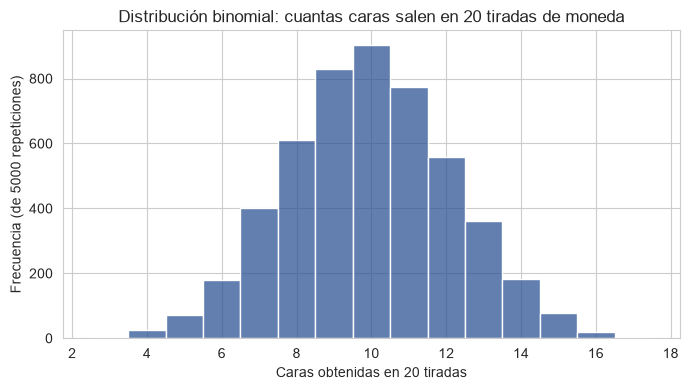

Promedio de caras: 9.95  (teórico: 20*0.5 = 10.0)


In [6]:
np.random.seed(2)                              # semilla fija
caras_por_experimento = [np.random.binomial(n=20, p=0.5) for _ in range(5000)]   # 5000 experimentos de "20 tiradas", guardamos cuantas caras salieron en cada uno

plt.figure(figsize=(7, 4))                     # mismo estilo de gráficos que usamos en la Clase 1
sns.histplot(caras_por_experimento, discrete=True, color="#2E5496")   # discrete=True: barras separadas, no un histograma continuo
plt.xlabel("Caras obtenidas en 20 tiradas")
plt.ylabel("Frecuencia (de 5000 repeticiones)")
plt.title("Distribución binomial: cuantas caras salen en 20 tiradas de moneda")
plt.tight_layout()
plt.show()

print(f"Promedio de caras: {np.mean(caras_por_experimento):.2f}  (teórico: 20*0.5 = 10.0)")

👨‍🏫 **Esa campana no es casualidad.** Es la forma que toma "contar éxitos en intentos
independientes" cuando el número de intentos es razonablemente grande. La vas a ver una y otra vez
-- es la misma forma que va a aparecer, por una razón totalmente distinta, en el Bloque D de hoy.

### 1.3 La distribución normal 👨‍🏫

La **distribución normal** (o gaussiana) es la campana continua: aparece cuando una variable es el
resultado de sumar muchos factores chicos e independientes (altura, errores de medición, tiempos de
reacción...). La reconocés por dos números: su centro (μ, "mu") y qué tan ancha es (σ, "sigma").

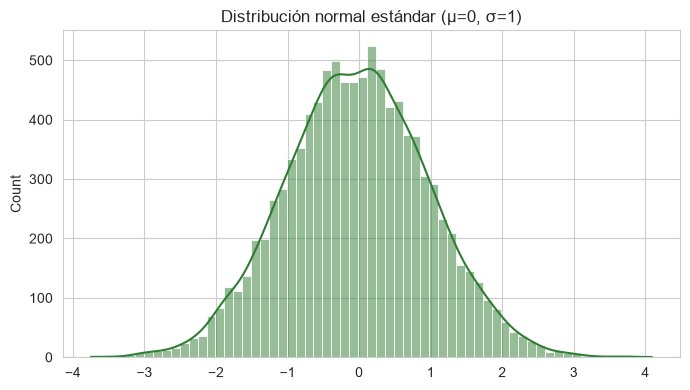

In [7]:
np.random.seed(3)                              # semilla fija
normal_sim = np.random.normal(loc=0, scale=1, size=10000)   # 10.000 valores de una normal con media 0 y desvio 1

plt.figure(figsize=(7, 4))
sns.histplot(normal_sim, kde=True, color="#2E7D32")   # kde=True agrega la curva suavizada sobre el histograma
plt.title("Distribución normal estándar (μ=0, σ=1)")
plt.tight_layout()
plt.show()

⚠️ **Por qué esto importa hoy y no antes:** la clase pasada vimos que el precio de Airbnb **no**
es normal (está sesgado, con esos anuncios de lujo tirando la cola para la derecha). Eso no fue un
capricho del dataset -- es la norma, no la excepción. La mayoría de los datos del mundo real no son
normales.

Y sin embargo, **toda la maquinaria clásica de inferencia está construida sobre la normal**. ¿Cómo se resuelve esa contradicción? Esa es exactamente la pregunta que responde el Bloque D.

---
## Bloque C -- Población y muestra: "una sola muestra miente"

### 2.1 Los dos niveles 👨‍🏫

- **Población**: todos los desarrolladores del mundo que podrían haber contestado esta encuesta.
  Nunca la vamos a ver completa.
- **Muestra**: los 1183 que efectivamente contestaron. Es lo único que tenemos.

Todo lo que calculamos sobre la muestra es una **estimación** de lo que pasa en la población -- y
esa estimación tiene un margen de error que hoy vamos a aprender a cuantificar.

💡 **La cuchara para probar la sopa.** En tu casa, cuando cocinan para dos, prueban la sal con
una cucharita. El domingo que vienen doce a comer, la olla es seis veces más grande -- pero la
cuchara para probar la sal **sigue siendo la misma cucharita**. El tamaño de la muestra que
necesitás no escala en proporción al tamaño de la población. Y ojo: si no revolvés la olla antes de
probar, no te salva una cuchara más grande -- el problema de una muestra no representativa no se
arregla agrandandola.

In [8]:
# Tomamos UNA muestra chica al azar y calculamos su media
np.random.seed(10)                             # semilla fija
muestra_chica = df["converted_comp_yearly"].sample(5)   # elige 5 filas al azar de la columna de sueldos
print("Una muestra de 5 personas:")
print(muestra_chica.to_string())               # to_string() muestra todos los valores, sin recortar
print(f"\nMedia de esta muestra: ${muestra_chica.mean():,.0f}")
print(f"Media real de las 1183: ${df['converted_comp_yearly'].mean():,.0f}")   # la referencia con TODOS los datos

Una muestra de 5 personas:
789      51403
188     107091
920      24045
1058    120000
936      80000

Media de esta muestra: $76,508
Media real de las 1183: $90,684


### 🤔 Predicción

¿Si volviera a tomar OTRA muestra de 5 personas al azar, la media te va a dar el mismo número de
arriba? ¿Por qué sí o por qué no? Escribilo en el chat antes de correr la celda siguiente.

In [9]:
# Repetimos con otra semilla -- otra muestra de 5
np.random.seed(99)                             # semilla DISTINTA a la de arriba -> otra muestra al azar
otra_muestra = df["converted_comp_yearly"].sample(5)
print(f"Nueva muestra de 5 -> media: ${otra_muestra.mean():,.0f}")
print(f"Media real de las 1183:      ${df['converted_comp_yearly'].mean():,.0f}")

Nueva muestra de 5 -> media: $100,567
Media real de las 1183:      $90,684


👨‍🏫 **Una sola muestra chica es un mal testigo.** Cada vez que la repetís te da un número
distinto, y ninguno de esos números individuales te dice cuánto confiar en él. Necesitamos una
manera de medir esa variabilidad -- no adivinarla. A eso vamos.

---
## Bloque D -- La distribución muestral, vista (no memorizada)

Vas a ver aparecer, con tus propios ojos, la idea más importante de la estadística inferencial --
sin que nadie te la dicte como fórmula.

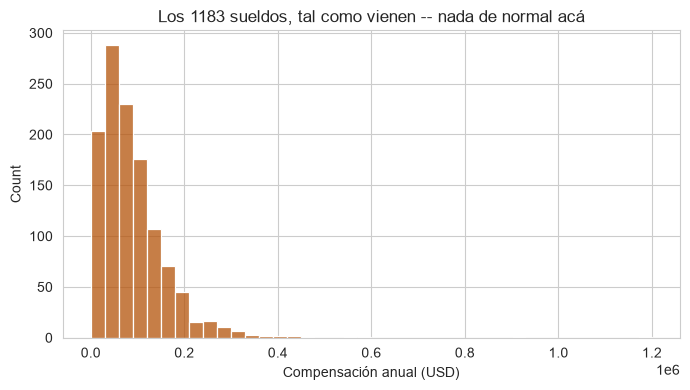

Asimetría (skew) de los datos crudos: 4.19
(una normal perfecta tiene skew = 0. Esto está lejísimos.)


In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(df["converted_comp_yearly"], bins=40, color="#B45309")  # histograma de los 1183 sueldos crudos
plt.xlabel("Compensación anual (USD)")
plt.title("Los 1183 sueldos, tal como vienen -- nada de normal acá")
plt.tight_layout()
plt.show()

print(f"Asimetría (skew) de los datos crudos: {stats.skew(df['converted_comp_yearly']):.2f}")  # stats.skew: 0 = simétrico, más alto = más sesgado a la derecha
print("(una normal perfecta tiene skew = 0. Esto está lejísimos.)")

### 🤔 Predicción -- la más importante del bloque

Vamos a tomar 1000 muestras de 5 personas cada una, calcular la media de cada muestra, y graficar
esas 1000 medias. Después vamos a repetir con muestras de 20 personas.

**Antes de ejecutar, escribí en el chat:** ¿creés que esas 1000 medias van a tener la misma forma
sesgada que el gráfico de arriba, o va a cambiar? Y si cambia, ¿para dónde?

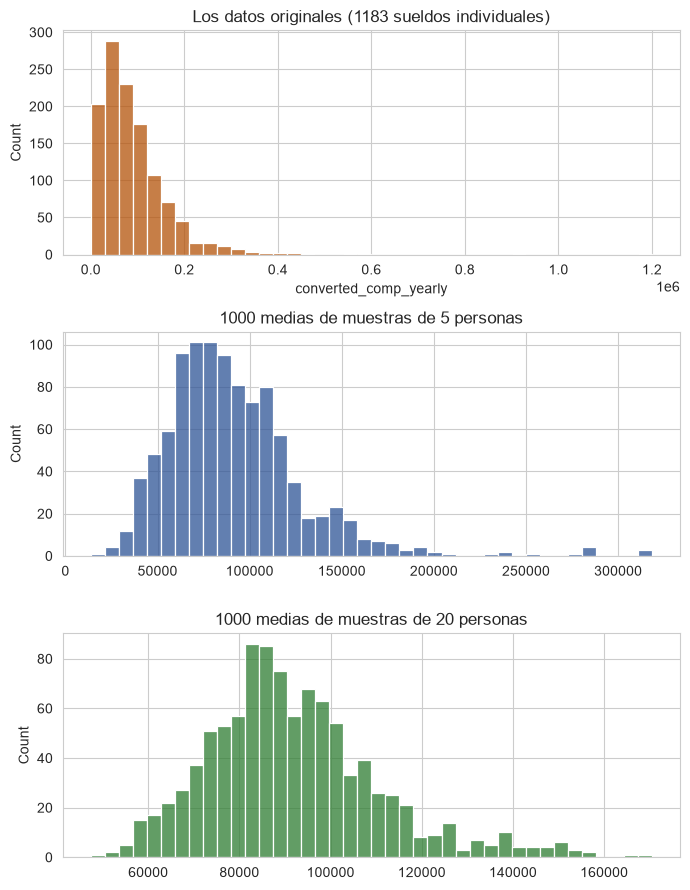

Asimetría de los datos originales:   4.19
Asimetría de las medias de 5:         1.81
Asimetría de las medias de 20:        0.85


In [11]:
np.random.seed(7)                                          # semilla fija: todos obtienen los mismos números al ejecutar
medias_de_5  = [df["converted_comp_yearly"].sample(5).mean()  for _ in range(1000)]   # 1000 muestras de 5 personas -> guardamos la media de cada una
medias_de_20 = [df["converted_comp_yearly"].sample(20).mean() for _ in range(1000)]   # lo mismo, pero con muestras de 20 personas

# OJO: este es el UNICO grafico de la clase que usa "fig, axes". Lo necesitamos porque son 3 paneles
# apilados y hay que decirle a cada uno donde dibujarse (ax=axes[0], axes[1], axes[2]).
# Para un grafico solo alcanza con plt.figure() + plt.title(), como en la Clase 1.
fig, axes = plt.subplots(3, 1, figsize=(7, 9))              # 3 gráficos apilados, uno debajo del otro

sns.histplot(df["converted_comp_yearly"], bins=40, ax=axes[0], color="#B45309")  # panel 1: los 1183 sueldos, sin tocar
axes[0].set_title("Los datos originales (1183 sueldos individuales)")

sns.histplot(medias_de_5, bins=40, ax=axes[1], color="#2E5496")   # panel 2: las 1000 medias de muestras CHICAS (n=5)
axes[1].set_title("1000 medias de muestras de 5 personas")

sns.histplot(medias_de_20, bins=40, ax=axes[2], color="#2E7D32")  # panel 3: las 1000 medias de muestras mas grandes (n=20)
axes[2].set_title("1000 medias de muestras de 20 personas")

plt.tight_layout()                                          # ajusta espacios para que los titulos no se pisen
plt.show()

# comparamos que tan sesgada (asimetrica) quedo cada distribucion -- este es el numero que cuenta la historia
print(f"Asimetría de los datos originales:   {stats.skew(df['converted_comp_yearly']):.2f}")
print(f"Asimetría de las medias de 5:         {stats.skew(medias_de_5):.2f}")
print(f"Asimetría de las medias de 20:        {stats.skew(medias_de_20):.2f}")

👨‍🏫 **Esto que acabas de ver es el Teorema del Límite Central (TLC), sin que lo hayamos
nombrado todavía.** No importa qué tan torcidos vengan los datos originales -- la distribución de
las **medias de muestras** se va pareciendo cada vez más a una campana a medida que la muestra
crece. Eso es lo único que el TLC promete.

Formalmente:

$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right) \quad \text{cuando } n \text{ es suficientemente grande}$$

Traducido: la distribución de las medias muestrales se acerca a una normal centrada en la media
poblacional real (μ), con una dispersión que se achica a medida que n crece.

⚠️ **La trampa en la que casi todo el mundo cae con este grafico -- inclusive profesores con
años de experiencia dando esta materia.** Mira las medias de las 1000 muestras de 20: su promedio da
un número MUY cercano a la media real de los 1183 (unos $90.684). Es tentador concluir *"a medida
que la muestra crece (n), la media se acerca más a la media real"*.

**Eso es falso, y es exactamente lo que un estudio publicado (Watkins, Bargagliotti & Franklin,
2014) documenta que la gente concluye mal al mirar este mismo tipo de grafico.** La versión correcta
es otra:

> **No importa cual sea el tamaño de muestra n, la distribución muestral de la media tiene media μ
> (la media poblacional real) y desviación σ/√n. Lo único que cambia con n es la FORMA -- se vuelve
> más parecida a una campana -- y qué tan angosta es esa campana. El centro no se mueve con n.**

Lo que viste arriba que "se acerca" a la media real con n=20 es un efecto de que promediamos muchas
repeticiones (1000), no del tamaño de cada muestra individual (20). Si repetimos con muestras de
tamaño 5 pero promediamos 100.000 repeticiones en vez de 1000, ese promedio también se va a acercar
mucho a la media real -- sin que n haya cambiado en nada.

### ✍️ TU TURNO 2

Repetí el experimento con muestras de tamaño **50**. Calculá la asimetría (`stats.skew`) de las 1000
medias resultantes y compará con las de 5 y 20 de arriba: ¿sigue bajando?

💡 *Pista: mismo patrón que la celda de arriba, cambiando `sample(5)` o `sample(20)` por
`sample(50)`.*

💡 *Segunda forma, la que vas a necesitar en la tarea:* en vez de `.sample()` de pandas, podés
trabajar sobre un **array de NumPy** y usar `np.random.choice`. Se hace en dos pasos:

```python
poblacion = df["converted_comp_yearly"].dropna().values   # .dropna() saca nulos, .values lo pasa a array
muestra = np.random.choice(poblacion, 50)                 # 50 valores al azar de ese array
```

Las dos formas dan lo mismo. La tarea usa esta segunda, así que conviene que la reconozcas.

In [12]:
# TU TURNO 2: 1000 medias de muestras de 50, calcular su asimetría
# Tu código aquí



---
## Bloque E -- Bootstrap: el error estándar sin ninguna fórmula

### 3.1 El problema 👨‍🏫

Ya sabemos que una sola muestra da una media que "baila". La pregunta natural es: **¿cuánto baila?**
A esa medida de cuánto varía un estadístico de muestra en muestra se la llama **error estándar**.

Para la media, existe una fórmula clásica: `σ/√n`. Pero, ¿qué hacemos si queremos el error estándar de la **mediana**? No hay una fórmula simple para eso en ningún curso introductorio. Acá es donde
entra el **bootstrap**.

👨‍🏫 **La idea del bootstrap, en una frase: si no podés volver a muestrear la población real,
remuestreá tu propia muestra, con reemplazo, miles de veces.** Cada remuestreo te da un valor del
estadístico que te interesa. La dispersión de esos miles de valores ES tu estimación del error
estándar -- sin ninguna fórmula, sirve para (casi) cualquier estadístico.

In [13]:
np.random.seed(11)                             # semilla fija
resultados_bootstrap = []                      # aca vamos a juntar 1000 medianas
for _ in range(1000):                          # repetimos el remuestreo 1000 veces
    muestra_boot = df["converted_comp_yearly"].sample(frac=1, replace=True)   # frac=1: mismo tamaño (1183) · replace=True: CON reemplazo (bootstrap)
    resultados_bootstrap.append(muestra_boot.median())   # guardamos la mediana de ESTE remuestreo
resultados_bootstrap = pd.Series(resultados_bootstrap)   # convertimos la lista en Series para poder usar .mean()/.std()

print("Bootstrap de la MEDIANA:")
print(f"  mediana real (con los 1183 datos): ${df['converted_comp_yearly'].median():,.0f}")
print(f"  media de las 1000 medianas bootstrap: ${resultados_bootstrap.mean():,.0f}")
print(f"  error estándar (desviación de las 1000 medianas): ${resultados_bootstrap.std():,.0f}")   # ESTO es el error estandar, sin ninguna formula

Bootstrap de la MEDIANA:
  mediana real (con los 1183 datos): $72,714
  media de las 1000 medianas bootstrap: $72,561
  error estándar (desviación de las 1000 medianas): $2,252


### ✍️ TU TURNO 3

Cambiá UNA sola palabra del código de arriba: en vez de `.median()`, usa `.mean()`. Volvé a correr
el bootstrap y compará el error estándar de la media contra el de la mediana que acabamos de
calcular.

💡 *Pista: copiá la celda de arriba, cambiá `.median()` por `.mean()` en la línea del `for`.*

In [14]:
# TU TURNO 3: bootstrap del ERROR ESTÁNDAR DE LA MEDIA (no la mediana)
# Tu código aquí



👨‍🏫 **Esa es la idea completa del "talla única" del bootstrap:** cambiaste una palabra y
obtuviste el error estándar de otro estadístico distinto. Con la fórmula clásica `σ/√n`, eso ni
siquiera existe para la mediana -- tendrias que buscar otra fórmula, si es que existe.

---
## Bloque F -- El intervalo de confianza: "no es un número, es un rango"

### 4.1 De un solo número a un rango honesto 👨‍🏫

Decir "la media es $90.684" sin decir nada de la incertidumbre es una afirmación incompleta. Un
**intervalo de confianza** es un rango de valores plausibles para el parámetro real, construido para
que, si repitiéramos el proceso muchas veces, el rango contenga al valor real un porcentaje conocido
de las veces (por ejemplo, 90%).

Con el bootstrap, construir un intervalo de confianza es literalmente **cortar los extremos del
histograma bootstrap**.

Con SOLO 20 personas, la media de la muestra da: $89,282
Intervalo de confianza del 90%: [$68,813, $113,901]

(La media real con los 1183 completos es $90,684 -- cae dentro del intervalo?)


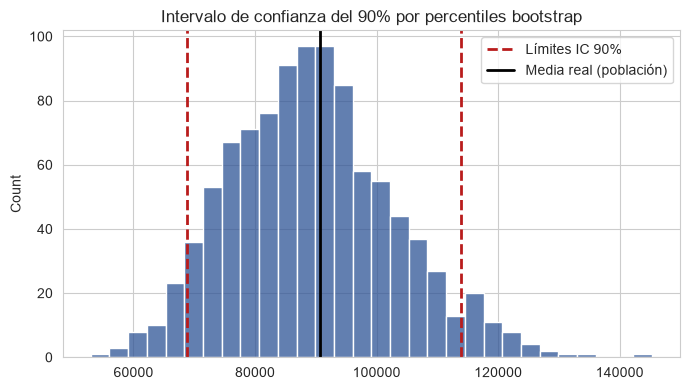

In [15]:
np.random.seed(3)                              # semilla fija
# Simulamos tener SOLO una muestra chica de 20 personas (no las 1183)
muestra_20 = df["converted_comp_yearly"].sample(20, random_state=3)   # random_state fija esta muestra especifica

medias_boot = []                               # aca vamos a juntar 1000 medias bootstrap
for _ in range(1000):
    remuestreo = muestra_20.sample(20, replace=True)   # remuestreamos DE LA MUESTRA de 20, no de los 1183 completos
    medias_boot.append(remuestreo.mean())
medias_boot = pd.Series(medias_boot)

ic_90 = medias_boot.quantile([0.05, 0.95])     # cortamos el 5% de cada punta -> queda el 90% del medio
print(f"Con SOLO 20 personas, la media de la muestra da: ${muestra_20.mean():,.0f}")
print(f"Intervalo de confianza del 90%: [${ic_90.iloc[0]:,.0f}, ${ic_90.iloc[1]:,.0f}]")
print(f"\n(La media real con los 1183 completos es ${df['converted_comp_yearly'].mean():,.0f}"
      f" -- cae dentro del intervalo?)")

plt.figure(figsize=(7, 4))
sns.histplot(medias_boot, bins=30, color="#2E5496")   # histograma de las 1000 medias bootstrap
plt.axvline(ic_90.iloc[0], color="#B91C1C", linestyle="--", lw=2, label="Límites IC 90%")   # línea vertical en el limite inferior
plt.axvline(ic_90.iloc[1], color="#B91C1C", linestyle="--", lw=2)   # y en el limite superior
plt.axvline(df["converted_comp_yearly"].mean(), color="black", lw=2, label="Media real (población)")   # la verdad, para comparar
plt.legend()
plt.title("Intervalo de confianza del 90% por percentiles bootstrap")
plt.tight_layout()
plt.show()

### 🤔 Predicción

Si en vez de 90% de confianza pidieramos 99% de confianza, ¿el intervalo va a ser **más angosto** o **más ancho**? Escribí tu respuesta antes de correr la celda de abajo.

In [16]:
ic_99 = medias_boot.quantile([0.005, 0.995])   # ahora cortamos solo 0.5% de cada punta -> queda el 99% del medio
print(f"IC 90%: [${ic_90.iloc[0]:,.0f}, ${ic_90.iloc[1]:,.0f}]  -- ancho: ${ic_90.iloc[1]-ic_90.iloc[0]:,.0f}")
print(f"IC 99%: [${ic_99.iloc[0]:,.0f}, ${ic_99.iloc[1]:,.0f}]  -- ancho: ${ic_99.iloc[1]-ic_99.iloc[0]:,.0f}")

IC 90%: [$68,813, $113,901]  -- ancho: $45,088
IC 99%: [$59,703, $126,404]  -- ancho: $66,701


👨‍🏫 **Más confianza siempre cuesta un intervalo más ancho.** Es el mismo trade-off que en
cualquier decisión bajo incertidumbre: pedir más seguridad te obliga a comprometerte con menos
precisión. No hay forma de tener las dos cosas gratis.

---
## Bloque G -- 🎬 ¿Los que usan IA ganan más?

Llegamos al momento central de la clase. Tenemos las herramientas: ahora las usamos para responder
una pregunta real, sobre gente real, en el mismo dataset que venimos mirando toda la clase.

In [17]:
usando = df.loc[df["plans_to_use_ai"] == "Using", "converted_comp_yearly"]        # sueldos de quienes YA usan IA
planea = df.loc[df["plans_to_use_ai"] == "Plan to use", "converted_comp_yearly"]  # sueldos de quienes PLANEAN usarla

print(f"Ya usan IA (n={len(usando)}):     media = ${usando.mean():,.0f}")
print(f"Planean usarla (n={len(planea)}): media = ${planea.mean():,.0f}")
print(f"\nDiferencia observada: ${usando.mean() - planea.mean():,.0f}")   # esta es la diferencia que vamos a poner a prueba

Ya usan IA (n=789):     media = $92,088
Planean usarla (n=394): media = $87,873

Diferencia observada: $4,215


### 🤔 Predicción -- la más importante de la clase

Ahí la tenés: los que ya usan IA ganan varios miles de dólares más, en promedio, que los que todavía
no. **Antes de seguir, escribí en el chat: ¿creés que esta diferencia es "real" (se sostendría en la población completa de developers) o podría ser puro azar de quien contestó la encuesta?**

Pensalo como si fueras vos quien tiene que decidir si esto es una noticia para publicar.

### 5.1 La lógica de la prueba de permutación 👨‍🏫

La pregunta que responde una prueba de permutación es exactamente esta: *si el hecho de "usar IA o
no" no tuviera **ningun** efecto real sobre el sueldo -- si fuera pura casualidad quien quedó en cada
grupo -- ¿qué tan seguido veríamos, solo por azar, una diferencia tan grande como la que observamos?*

La forma de responderla sin ninguna fórmula: **juntá los 1183 sueldos en una sola bolsa. Repartilos
al azar en dos grupos, uno del tamaño de "Using" y otro del tamaño de "Plan to use". Calculá la
diferencia de medias de esos dos grupos barajados. Repetilo miles de veces.** Eso te da la
distribución de diferencias que se producen solo por azar, sin que "usar IA" tenga ningún efecto
real.

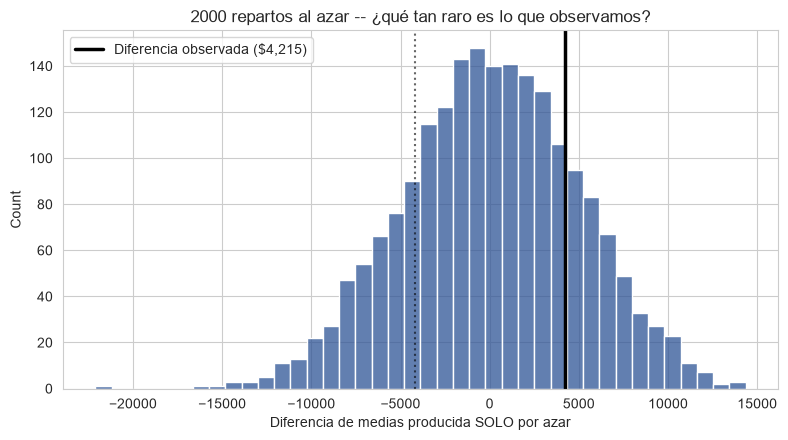

De las 2000 veces que repartimos al azar, en el 39.8% de ellas
el azar solo ya produjo una diferencia igual o mas grande que la que observamos.


In [18]:
def perm_fun(x, nA, nB):                       # x = todos los sueldos juntos; nA, nB = tamaño de cada grupo
    n = nA + nB
    idx_A = set(np.random.choice(n, nA, replace=False))   # elige AL AZAR nA posiciones para el grupo A
    idx_B = set(range(n)) - idx_A                 # el resto de las posiciones va al grupo B
    return x.iloc[list(idx_A)].mean() - x.iloc[list(idx_B)].mean()   # diferencia de medias de este reparto al azar

np.random.seed(42)                             # semilla fija
combinado = pd.concat([usando, planea]).reset_index(drop=True)   # los 1183 sueldos, TODOS juntos en una sola bolsa
diferencia_observada = usando.mean() - planea.mean()   # la diferencia REAL, la que vimos en los datos

diferencias_al_azar = np.array([perm_fun(combinado, len(usando), len(planea)) for _ in range(2000)])   # 2000 repartos al azar de esa bolsa

plt.figure(figsize=(8, 4.5))
sns.histplot(diferencias_al_azar, bins=40, color="#2E5496")   # como se distribuyen las 2000 diferencias al azar
plt.axvline(diferencia_observada, color="black", lw=2.5, label=f"Diferencia observada (${diferencia_observada:,.0f})")   # donde cae lo que vimos de verdad
plt.axvline(-diferencia_observada, color="black", lw=1.5, linestyle=":", alpha=0.6)   # el espejo del otro lado, para ver simetria
plt.legend()
plt.xlabel("Diferencia de medias producida SOLO por azar")
plt.title("2000 repartos al azar -- ¿qué tan raro es lo que observamos?")
plt.tight_layout()
plt.show()

p_valor_permutacion = np.mean(np.abs(diferencias_al_azar) >= abs(diferencia_observada))   # que fraccion del azar iguala o supera lo observado
print(f"De las 2000 veces que repartimos al azar, en el {p_valor_permutacion*100:.1f}% de ellas")
print(f"el azar solo ya produjo una diferencia igual o mas grande que la que observamos.")

👨‍🏫 **Mirá bien esa imagen: es literalmente la definición de un p-value.** La línea negra es
lo que observamos en los datos reales. El histograma completo es "lo que produce el puro azar,
miles de veces". La pregunta del p-value es: *¿qué fracción del histograma queda tan lejos, o más
lejos, que mi línea negra?* Nada más que eso.

### ✍️ TU TURNO 4

Repetí la prueba de permutación pero comparando la **mediana** en vez de la media (menos sensible a
sueldos extremos). ¿Cambia mucho la conclusión?

💡 *Pista: copia `perm_fun` y cambiale `.mean()` por `.median()`; o simplemente calculá
`usando.median() - planea.median()` y compara contra una versión de `diferencias_al_azar` calculada
con medianas.*

In [19]:
# TU TURNO 4: repetir la prueba de permutación comparando MEDIANAS en vez de medias
# Tu código aquí



---
## Bloque H -- El p-value: qué es, y sobre todo, qué NO es

Ya calculaste un p-value en el bloque anterior sin que lo llamemos por su nombre. Ahora le ponemos
nombre y, más importante, le ponemos límites.

In [20]:
print(f"p-value de la comparación 'usan IA' vs 'planean usarla': {p_valor_permutacion:.3f}")   # el mismo numero que calculamos en el Bloque G

p-value de la comparación 'usan IA' vs 'planean usarla': 0.398


👨‍🏫 **Definición correcta:** el p-value es la probabilidad de observar una diferencia igual o
más extrema que la que vimos, **si asumimos que no hay ningún efecto real** (esto se llama la
*hipótesis nula*, H0). Es una medida de cuánto contradicen los datos a esa hipótesis de "no hay
efecto" -- nada más.

⚠️ **Lo que el p-value NO es, aunque sea la confusión más común del mundo de los datos** -- y esto
no es una opinión nuestra, es literalmente la declaración oficial de la American Statistical
Association (2016):

1. **NO es** la probabilidad de que la hipótesis nula sea verdadera.
2. **NO es** la probabilidad de que el resultado se deba al azar.
3. **Un p-value no decide solo.** Ninguna conclusión seria (científica, legal, de negocio) se apoya
   en si un número quedó de un lado o del otro de 0.05.
4. Un p-value chico **no prueba** que el efecto sea importante en la práctica -- con suficientes
   datos, hasta una diferencia diminuta e irrelevante puede dar un p-value chiquito.
5. Un p-value grande **no prueba** que no haya efecto -- solo dice que con estos datos no lo pudimos
   detectar.

💡 **Los binoculares.** Si mirás dos animales de la misma especie con binoculares cada vez más
potentes (más datos), en algún momento vas a "ver" diferencias entre ellos -- un pelo distinto, un
bigote más largo. Esas diferencias son reales en el sentido de que las medís, pero no significan que
sean **animales distintos**. Más datos (más aumento) siempre te van a mostrar diferencias; la
pregunta de si esas diferencias importan es otra pregunta, y el p-value solo no la responde.

### 5.2 El vocabulario que vas a encontrar afuera 👨‍🏫

Toda la clase de hoy la hicimos **sin fórmulas y sin jerga**: remuestreamos, contamos y miramos.
Pero el video del campus, la tarea, los papers y cualquier software que uses van a hablar con otro
vocabulario. Es el mismo razonamiento, con otros nombres. Traducción:

| Lo que dijimos hoy | Cómo se llama formalmente |
|---|---|
| "supongamos que no hay ningún efecto" | **Hipótesis nula**, se escribe **H₀** |
| "supongamos que sí hay un efecto" | **Hipótesis alternativa**, **H₁** (o **Hₐ**) |
| "el umbral de 0.05 que usamos para decidir" | **Nivel de significancia**, la letra griega **α** (alfa) |
| "concluimos que hay efecto cuando en realidad no lo había" | **Error de Tipo I** (falso positivo) |
| "no detectamos un efecto que sí existía" | **Error de Tipo II** (falso negativo) |

⚠️ **Una precisión de lenguaje que importa más de lo que parece.** Cuando el p-value sale grande, lo
correcto es decir **"no rechazamos H₀"** -- no *"aceptamos H₀"*. No es lo mismo: no encontrar
evidencia de un efecto no prueba que el efecto no exista. Es exactamente lo que vimos en el Bloque G:
la diferencia de $4.215 entre los dos grupos **podría ser real** -- solo que con estos datos no
podemos demostrarlo. Vas a escuchar "aceptar la hipótesis nula" seguido; sabé que es una forma
relajada de hablar, y que dice más de lo que los datos permiten.

### 5.3 El puente con la unidad de Bayes 👨‍🏫

En una línea: el p-value responde **"qué tan probables son estos datos si no hay efecto"**
— P(datos | hipótesis) — y lo que en el fondo todos queremos saber es lo inverso,
**"qué tan probable es que haya un efecto dado lo que vi"** — P(hipótesis | datos), que es la
pregunta bayesiana. **Son distintas, y el p-value solo responde la primera.**

📌 *Confundirlas tiene nombre propio en el derecho penal — la **falacia del fiscal** — y un caso
real: la condena de Sally Clark (Reino Unido, 1999), anulada años después justamente por ese error
estadístico. Queda de lectura para después de clase.*

### Respondiendo la pregunta de hoy 👨‍🏫

**"¿Puedo confiar en lo que vi, o tuve suerte?"**

Con el dato crudo, alguien que solo sabe apretar `.mean()` diria: *"los que usan IA ganan unos
$4.200 más"*, punto. Esa es la respuesta ingenua.

La respuesta completa es: la diferencia observada es real en los datos, pero un reparto puramente al
azar produce una diferencia igual o mayor una fracción importante de las veces (mira el número exacto
que calculaste arriba, en `p_valor_permutacion`). Con este tamaño de muestra, **no hay evidencia
suficiente para decir que usar IA esté asociado a un sueldo mayor**. Podria estar pasando -- pero
estos datos no alcanzan para probarlo.

---
## Bloque I -- El atajo de 1908

Todo lo que hicimos en el Bloque G -- remuestrear, contar, graficar -- tiene un atajo matemático que
da (casi) el mismo resultado en una sola línea. Se llama **t-test**, y lo inventó un estadístico
inglés en 1908 (firmando como "Student", porque su empleador -- la cervecería Guinness -- no
permitía publicar bajo nombre real).

In [21]:
t_stat, p_valor_ttest = stats.ttest_ind(usando, planea, equal_var=False)   # equal_var=False: version Welch, no asume igual dispersion

print(f"t-test (Welch):  t = {t_stat:.4f}   p = {p_valor_ttest:.4f}")
print(f"Permutación (Bloque G):          p = {p_valor_permutacion:.4f}")
print(f"\nDiferencia entre los dos métodos: {abs(p_valor_ttest - p_valor_permutacion):.4f}")   # que tan cerca quedaron el atajo y el metodo largo

t-test (Welch):  t = 0.9293   p = 0.3529
Permutación (Bloque G):          p = 0.3975

Diferencia entre los dos métodos: 0.0446


👨‍🏫 **Casi el mismo número, en una línea de código en vez de diez.** Esa es la razón por la
que el t-test se volvió el estándar: antes de las computadoras, remuestrear miles de veces a mano
era impensable, y esta aproximación matemática daba (bajo ciertos supuestos) prácticamente la misma
respuesta.

Hoy la computadora hace las 2000 repeticiones en un segundo -- por eso empezamos por ahí. Pero el
t-test sigue siendo lo que vas a ver en el 90% del software y los papers que te vas a cruzar, así
que hay que saber leerlo.

⚠️ Fijate que usamos `equal_var=False` (el test de Welch): no asumimos que los dos grupos tienen la
misma dispersión. Es la versión más segura por defecto -- asumir varianzas iguales cuando no lo son
es otro supuesto que conviene no dar por sentado sin chequear.

### 6.1 El otro t-test: una muestra contra un valor de referencia 👨‍🏫

El `ttest_ind` que acabamos de usar compara **dos grupos entre sí**. Pero hay otro caso muy común:
tenés **una sola muestra** y la querés comparar contra **un número de referencia** que viene de
afuera (un informe de la industria, una meta de la empresa, el promedio del año pasado).

Para eso está `stats.ttest_1samp` -- "1 sample", una sola muestra. Y trae dos parámetros que hay
que conocer sí o sí, porque **la tarea de esta clase los pide**:

- `popmean=` : el valor de referencia contra el que comparás.
- `alternative=` : qué estás preguntando exactamente.
  - `'two-sided'` (el valor por defecto) -> *"¿es distinto de X?"*, sin importar para qué lado.
  - `'greater'` -> *"¿es **mayor** que X?"*
  - `'less'` -> *"¿es **menor** que X?"*

In [22]:
# Supongamos que un informe de la industria dice que el sueldo de referencia es $86.500
# y queremos saber si nuestra muestra de developers gana MAS que eso.

t_uno, p_uno = stats.ttest_1samp(df["converted_comp_yearly"], popmean=86500, alternative="greater")
print(f"Pregunta correcta ('ganan MAS que 86.500?'):   t = {t_uno:.4f}   p = {p_uno:.4f}")

# Ahora la MISMA línea, pero olvidandonos de escribir alternative:
t_def, p_def = stats.ttest_1samp(df["converted_comp_yearly"], popmean=86500)
print(f"Sin escribir alternative (queda 'two-sided'):  t = {t_def:.4f}   p = {p_def:.4f}")

print(f"\n¿El estadístico t es el mismo?  {t_uno == t_def}")
print(f"¿El p-value es exactamente el doble?  {abs(p_def - 2*p_uno) < 1e-12}")

Pregunta correcta ('ganan MAS que 86.500?'):   t = 1.7574   p = 0.0396
Sin escribir alternative (queda 'two-sided'):  t = 1.7574   p = 0.0791

¿El estadístico t es el mismo?  True
¿El p-value es exactamente el doble?  True


💥 **Mirá bien lo que acaba de pasar, porque es la trampa más fácil de comer en toda la tarea.**

El `t` salió **idéntico** en los dos casos. Lo único que cambió fue el p-value: se **duplicó**
exacto. Y con el umbral habitual de 0.05, eso da vuelta la conclusión completa:

| Cómo lo escribiste | p-value | Conclusión con α = 0.05 |
|---|---|---|
| `alternative="greater"` (la pregunta que querías hacer) | ≈ 0.040 | **Significativo** -- hay evidencia |
| Sin `alternative` (te lo olvidaste) | ≈ 0.079 | **No significativo** -- no hay evidencia |

**Misma línea de código, mismo `t`, conclusión opuesta.** Y Python no te avisa: no hay error, no hay
warning, el número sale limpio y con cara de correcto.

⚠️ **Esto te va a pasar en la tarea.** El `Assignment 2` pide explícitamente una prueba de una cola
(`alternative='less'`), y publica el resultado esperado. Si tu `t` coincide pero tu p-value es el
doble del publicado, ya sabés exactamente qué te olvidaste.

### ✍️ TU TURNO 5

Interpretá en una frase el resultado del t-test de arriba, como si se lo tuvieras que explicar a tu
jefe que nunca escucho hablar de un p-value. No copies la definición formal -- traducila a español
de trabajo.

💡 *Pista: pensá en términos de "con estos datos, no hay evidencia suficiente para..." o "los datos
sugieren fuertemente que...", según corresponda al número que te dio.*

In [23]:
# TU TURNO 5: escribí tu interpretación como comentario, en español de trabajo
# Tu código aquí



---
## Bloque J -- Cierre: lo que aprendimos hoy

### El error que no truena -- y por qué es peor que el que sí truena 👨‍🏫

En la Clase 1 tuvimos un error que **gritaba**: un `ValueError` bien ruidoso al intentar convertir
texto en número. Hoy vamos a ver uno de otro tipo -- **uno que no dice nada**.

Repasá: la columna `plans_to_use_ai` solo tiene los valores `"Using"` y `"Plan to use"`, con
mayúscula inicial. ¿Qué pasa si escribimos el filtro con minúscula, un typo común de cualquiera que está escribiendo rápido?

### 🤔 Predicción

Antes de ejecutar: ¿la celda de abajo va a tirar un error (como el `ValueError` de la clase pasada), o va a "funcionar" sin quejarse? Escribí SÍ (tira error) o NO (no tira error) en el chat.

In [24]:
grupo_con_typo = df.loc[df["plans_to_use_ai"] == "using", "converted_comp_yearly"]  # minúscula! el archivo dice "Using"

print(f"Filas encontradas: {len(grupo_con_typo)}")   # ninguna fila coincide con el filtro mal escrito
print(f"Media calculada: {grupo_con_typo.mean()}")   # el promedio de CERO filas -> nan, sin ningún error

Filas encontradas: 0
Media calculada: nan


💥 **Ahí está -- y fijate que no hubo ningún `ValueError`.** El filtro con minúscula no
encontro NINGUNA fila (porque en el archivo dice `"Using"`, con mayúscula), pandas no se queja por
eso -- te devuelve, en silencio, una tabla vacía. Y el promedio de una tabla vacía es `nan`, también
en silencio.

Miremos que pasa si ese `nan` sigue viaje hacia un test estadístico:

In [25]:
import warnings
with warnings.catch_warnings(record=True) as advertencias:   # capturamos los warnings en vez de dejarlos pasar
    warnings.simplefilter("always")                # que muestre el warning aunque ya haya salido antes
    t_roto, p_roto = stats.ttest_ind(grupo_con_typo, planea, equal_var=False)   # comparamos el grupo VACIO contra el real
    for a in advertencias:                         # recorremos los warnings que se hayan disparado
        print(f"⚠️  Python SÍ avisa, pero como warning, no como error: {a.category.__name__}")

print(f"\nResultado: t = {t_roto}   p = {p_roto}")   # ambos dan nan -- sin ninguna excepcion que frene el programa
print("\nSi este número llega a un reporte sin que nadie lo mire de cerca, nadie se entera del error.")

⚠️  Python SÍ avisa, pero como warning, no como error: SmallSampleWarning

Resultado: t = nan   p = nan

Si este número llega a un reporte sin que nadie lo mire de cerca, nadie se entera del error.


👨‍🏫 **La lección no es "cuidado con las mayúsculas".** Es más grande que eso: **que el código
corra sin tirar una excepción NO significa que el resultado sea correcto.** El error de la clase
pasada era ruidoso e imposible de ignorar. Este es silencioso y facilísimo de dejar pasar -- vos
mismo lo hubieras dejado pasar si no estuviéramos mirando la salida con lupa.

💡 **La defensa es simple y la vas a usar toda tu carrera:** antes de filtrar por una columna de
texto, mirá sus valores únicos con `.unique()` o `.value_counts()` -- ya lo hicimos al principio de
la clase. Y desconfiá de cualquier resultado vacío o `nan` que aparezca donde esperabas un número.

### ⭐ Desafío opcional -- el caso Imanishi-Kari

En 1991, una investigadora de Tufts University fue acusada de fabricar datos de laboratorio. Parte
de la evidencia en su contra fue puramente estadística: si los dígitos **del medio** de sus mediciones
(ignorando el primero y el último) fueran genuinos, deberían estar distribuidos de forma
prácticamente uniforme entre 0 y 9 -- cada digito aparece, más o menos, la misma cantidad de veces,
porque nadie "elige" a propósito el digito del medio de una medición real.

Los investigadores contaron 315 dígitos del medio en sus datos:

In [26]:
imanishi = pd.DataFrame({
    "digito": list(range(10)),                 # los 10 dígitos posibles, del 0 al 9
    "frecuencia": [14, 71, 7, 65, 23, 19, 12, 45, 53, 6],   # cuantas veces aparecio cada uno en los datos reales del caso
})
print(imanishi)
print(f"\nTotal de dígitos: {imanishi['frecuencia'].sum()}")   # suma de la columna frecuencia = 315
print(f"Si fuera perfectamente uniforme, cada digito apareceria: {imanishi['frecuencia'].sum()/10:.1f} veces")   # 315 dividido 10 posibles dígitos

   digito  frecuencia
0       0          14
1       1          71
2       2           7
3       3          65
4       4          23
5       5          19
6       6          12
7       7          45
8       8          53
9       9           6

Total de dígitos: 315
Si fuera perfectamente uniforme, cada digito apareceria: 31.5 veces


**Desafío:** usá `stats.chisquare()` sobre la columna `frecuencia` para probar si esta
distribución es consistente con el azar uniforme, o si hay evidencia de que los números fueron
inventados. Ni el libro de referencia de esta clase ni el material oficial del curso corren
efectivamente este cálculo -- lo dejan como afirmación. Acá lo vas a calcular vos.

💡 *Pista: `stats.chisquare(imanishi["frecuencia"])` te da el estadístico y el p-value directo
(por defecto asume que la frecuencia esperada es uniforme).*

🤔 **Predicción antes de ejecutar:** con un grafico de barras tan irregular como el que vas a ver
¿si graficás `imanishi`, esperás un p-value grande o chiquito?

In [27]:
# ⭐ DESAFÍO 1: chi-cuadrado sobre los dígitos de Imanishi-Kari
# Tu código aquí



> **El giro final del caso, y por qué importa:** el resultado que vas a obtener es un p-value
> extremadamente chico -- de los más chicos que vas a ver en tu vida. Y sin embargo,
> **Imanishi-Kari fue finalmente exonerada**, tras un proceso larguísimo. Un p-value minúsculo es
> evidencia fuerte contra la hipótesis nula -- pero "evidencia fuerte" no es lo mismo que "prueba
> definitiva", y una decisión real (científica, legal, de negocio) nunca se apoya en un solo número.
> Es el mismo punto 3 de la lista de la ASA que vimos en el Bloque H, con nombre y apellido detrás.

### Lo que dominás ahora

| Concepto | Función de Python | Cuándo usarlo |
|---|---|---|
| Distribución de probabilidad | `np.random.binomial`, `np.random.normal` | Simular un proceso incierto |
| Distribución muestral | `.sample(n).mean()` repetido | Ver como varia un estadístico entre muestras |
| Bootstrap | `.sample(frac=1, replace=True)` | Error estándar de CUALQUIER estadístico, sin fórmula |
| Intervalo de confianza | `.quantile([0.05, 0.95])` sobre el bootstrap | Dar un rango, no un solo número |
| Prueba de permutación | remuestrear sin reemplazo, comparar grupos | Ver si una diferencia entre grupos es "real" |
| p-value | `np.mean(np.abs(diferencias_al_azar) >= abs(observada))` o `stats.ttest_ind` | Medir qué tan compatibles son los datos con "no hay efecto" |
| t-test | `stats.ttest_ind(a, b, equal_var=False)` | El atajo de 1908 para comparar dos grupos numéricos |

### Las ideas que valen más que las funciones

1. Una sola muestra chica es un mal testigo -- por eso existe la distribución muestral.
2. El Teorema del Límite Central habla de la FORMA de la distribución muestral, no de que el centro
   se acerque a la media real al crecer n -- eso ya era cierto para cualquier n.
3. El bootstrap te da el error estándar de cualquier estadístico, sin memorizar una fórmula por
   cada uno.
4. Más confianza en un intervalo siempre cuesta un intervalo más ancho. No hay atajo gratis.
5. Un p-value mide compatibilidad de los datos con "no hay efecto" -- NO es la probabilidad de que
   la hipótesis nula sea verdadera.
6. Un resultado no significativo no es un fracaso: es información real sobre los límites de lo que
   estos datos pueden probar.
7. Que el código no tire una excepción no significa que el resultado esté bien. El silencio también
   puede ser un error.
8. `.value_counts()` antes de filtrar por texto. Siempre.

### ⚠️ Advertencia final: un p-value no cierra el debate

Todo lo que calculamos hoy nos dice si una diferencia observada es compatible con el puro azar. **No
nos dice si esa diferencia importa en la práctica**, ni prueba que la hipótesis nula sea cierta o
falsa con certeza. La próxima clase (Regresión) vamos a usar estas mismas ideas -- muestra, error,
incertidumbre -- para predecir, no solo comparar.

### La tarea

`Assignment 2` oficial de Khipus, sobre `coffee_quality.csv` -- aplica el mismo par de ideas
(distribución muestral por remuestreo + prueba de hipótesis de una muestra) a un dataset distinto:
calidad sensorial de cafés de origen. Trae los resultados esperados publicados, así que te
autoverificas.

**Antes de calcular nada**, aplicá el método que ya conoces de la Clase 1: `head()`, `info()`,
buscar nulos y duplicados. La suciedad de los datos es parte del ejercicio, no un obstáculo.